# Epilepsy Detection: Data Loading & Preprocessing Pipeline

This notebook covers:
1. **Data Loading** from Bonn dataset
2. **Visualization** of EEG signals
3. **Basic Preprocessing** (filtering, normalization)
4. **Advanced Preprocessing**:
   - Variational Mode Decomposition (VMD)
   - Entropy-based feature extraction
   - Feature selection and fusion
   - ADASYN for class imbalance

**Output**: Preprocessed data ready for model training

## Installation and Imports

In [1]:
import os
os.chdir('/Users/shruthinagappan/Documents/Anvaya/venv_tf')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from os import listdir
from os.path import isfile, join
import warnings
warnings.filterwarnings('ignore')

# Signal processing
from vmdpy import VMD
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.stats import entropy as scipy_entropy

# Entropy measures
import antropy as ant

# Feature selection and preprocessing
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Class imbalance handling
from imblearn.over_sampling import ADASYN, SMOTE

# Model selection
from sklearn.model_selection import train_test_split

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 1.26.4
Pandas version: 3.0.1


## Data Loading from Bonn Dataset

### Dataset Structure (Sets A–E):
Each set contains **100 single-channel EEG segments** of **23.6-sec duration**, recorded at **173.61 Hz** with a 128-channel amplifier (bandpass: 0.53–40 Hz).

| Set | Folder | Description |
|-----|--------|-------------|
| **A** | `Z` | Healthy volunteers, **eyes open** (surface EEG) |
| **B** | `O` | Healthy volunteers, **eyes closed** (surface EEG) |
| **C** | `N` | Epileptic patients, **seizure-free interval** — hippocampal formation, **opposite hemisphere** |
| **D** | `F` | Epileptic patients, **seizure-free interval** — **epileptogenic zone** (hippocampal formation) |
| **E** | `S` | Epileptic patients — **ictal (seizure) activity**, all sites exhibiting ictal activity |

### Labeling (3-class):
- **Healthy (0)**: Sets A & B (folders Z, O) — normal brain activity
- **Interictal (1)**: Sets C & D (folders N, F) — epileptic patients, seizure-free intervals
- **Ictal (2)**: Set E (folder S) — active seizure activity

In [3]:

mapping_set_to_dir = {
    'A': (0, 'Z', 'Healthy - Eyes Open (surface EEG)'),
    'B': (1, 'O', 'Healthy - Eyes Closed (surface EEG)'),
    'C': (2, 'N', 'Interictal - Seizure-free, Opposite Hippocampal Hemisphere'),
    'D': (3, 'F', 'Interictal - Seizure-free, Epileptogenic Zone (Hippocampal)'),
    'E': (4, 'S', 'Ictal - Active Seizure Activity'),
}

# 3-class labels:
labels_map = {'Z': 0, 'O': 0, 'N': 1, 'F': 1, 'S': 2}

print("Dataset mapping (3-class):")
print("  Class 0: Healthy  (Sets A & B — normal brain activity)")
print("  Class 1: Interictal (Sets C & D — epileptic, seizure-free interval)")
print("  Class 2: Ictal    (Set  E   — active seizure activity)")
print("\nFolder assignments:")
for set_name, (idx, folder, description) in mapping_set_to_dir.items():
    label = labels_map[folder]
    print(f"  Set {set_name} - Folder {folder}: {description} - Label: {label}")

Dataset mapping (3-class):
  Class 0: Healthy  (Sets A & B — normal brain activity)
  Class 1: Interictal (Sets C & D — epileptic, seizure-free interval)
  Class 2: Ictal    (Set  E   — active seizure activity)

Folder assignments:
  Set A - Folder Z: Healthy - Eyes Open (surface EEG) - Label: 0
  Set B - Folder O: Healthy - Eyes Closed (surface EEG) - Label: 0
  Set C - Folder N: Interictal - Seizure-free, Opposite Hippocampal Hemisphere - Label: 1
  Set D - Folder F: Interictal - Seizure-free, Epileptogenic Zone (Hippocampal) - Label: 1
  Set E - Folder S: Ictal - Active Seizure Activity - Label: 2


In [4]:
file_lists = []
data_found = False

for s, (idx, folder, desc) in mapping_set_to_dir.items():
    try:
        path = f'dataset/{folder}'
        files = [f for f in listdir(path) if isfile(join(path, f)) and (f.endswith('.txt') or f.endswith('.TXT'))]
        file_lists.insert(idx, (path, files))
        print(f"✓ Found {len(files)} files in {path}")
        data_found = True
    except:
        try:
            path = folder
            files = [f for f in listdir(path) if isfile(join(path, f)) and (f.endswith('.txt') or f.endswith('.TXT'))]
            file_lists.insert(idx, (path, files))
            print(f"Found {len(files)} files in {path}")
            data_found = True
        except Exception as e:
            print(f"Could not find {folder}: {e}")
            file_lists.insert(idx, (None, []))

if not data_found:
    print("\nNo data found! Please ensure your data is in one of these structures:")

✓ Found 100 files in dataset/Z
✓ Found 100 files in dataset/O
✓ Found 100 files in dataset/N
✓ Found 100 files in dataset/F
✓ Found 100 files in dataset/S


In [5]:
def load_eeg_data(folder_path, file_list):
    """
    Load EEG data from text files
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing files
    file_list : list
        List of filenames to load
    
    Returns:
    --------
    data : ndarray
        Array of shape (n_signals, signal_length)
    """
    data = []
    for filename in file_list:
        if filename.endswith('.txt') or filename.endswith('.TXT'):
            filepath = join(folder_path, filename)
            try:
                signal_data = np.loadtxt(filepath)
                data.append(signal_data)
            except Exception as e:
                print(f"  Error loading {filename}: {e}")
    return np.array(data)

# Load all datasets
datasets = {}
all_signals = []
all_labels = []

print("\nLoading data")
for set_name, (idx, folder, desc) in mapping_set_to_dir.items():
    if idx < len(file_lists) and file_lists[idx][0] is not None:
        path, files = file_lists[idx]
        data = load_eeg_data(path, files)
        
        if len(data) > 0:
            datasets[folder] = data
            label = labels_map[folder]
            
            # Store in combined arrays
            all_signals.extend(data)
            all_labels.extend([label] * len(data))
            
            print(f"Loaded {folder}: {data.shape} - Label: {label}")

# Convert to numpy arrays
all_signals = np.array(all_signals)
all_labels = np.array(all_labels)

print(f"Total signals loaded: {len(all_signals)}")
print(f"Signal shape: {all_signals[0].shape if len(all_signals) > 0 else 'N/A'}")
print(f"Sampling rate: 173.61 Hz (from Bonn dataset specs)")
print(f"Duration per signal: ~23.6 seconds")
print(f"\nClass distribution:")
print(f"  Class 0 (Healthy): {np.sum(all_labels==0)} signals")
print(f"  Class 1 (Interictal): {np.sum(all_labels==1)} signals")
print(f"  Class 2 (Ictal): {np.sum(all_labels==2)} signals")
unique_labels = np.unique(all_labels)
print(f"\nNumber of classes: {len(unique_labels)}")


Loading data
Loaded Z: (100, 4097) - Label: 0
Loaded O: (100, 4097) - Label: 0
Loaded N: (100, 4097) - Label: 1
Loaded F: (100, 4097) - Label: 1
Loaded S: (100, 4097) - Label: 2
Total signals loaded: 500
Signal shape: (4097,)
Sampling rate: 173.61 Hz (from Bonn dataset specs)
Duration per signal: ~23.6 seconds

Class distribution:
  Class 0 (Healthy): 200 signals
  Class 1 (Interictal): 200 signals
  Class 2 (Ictal): 100 signals

Number of classes: 3


## Data Visualization

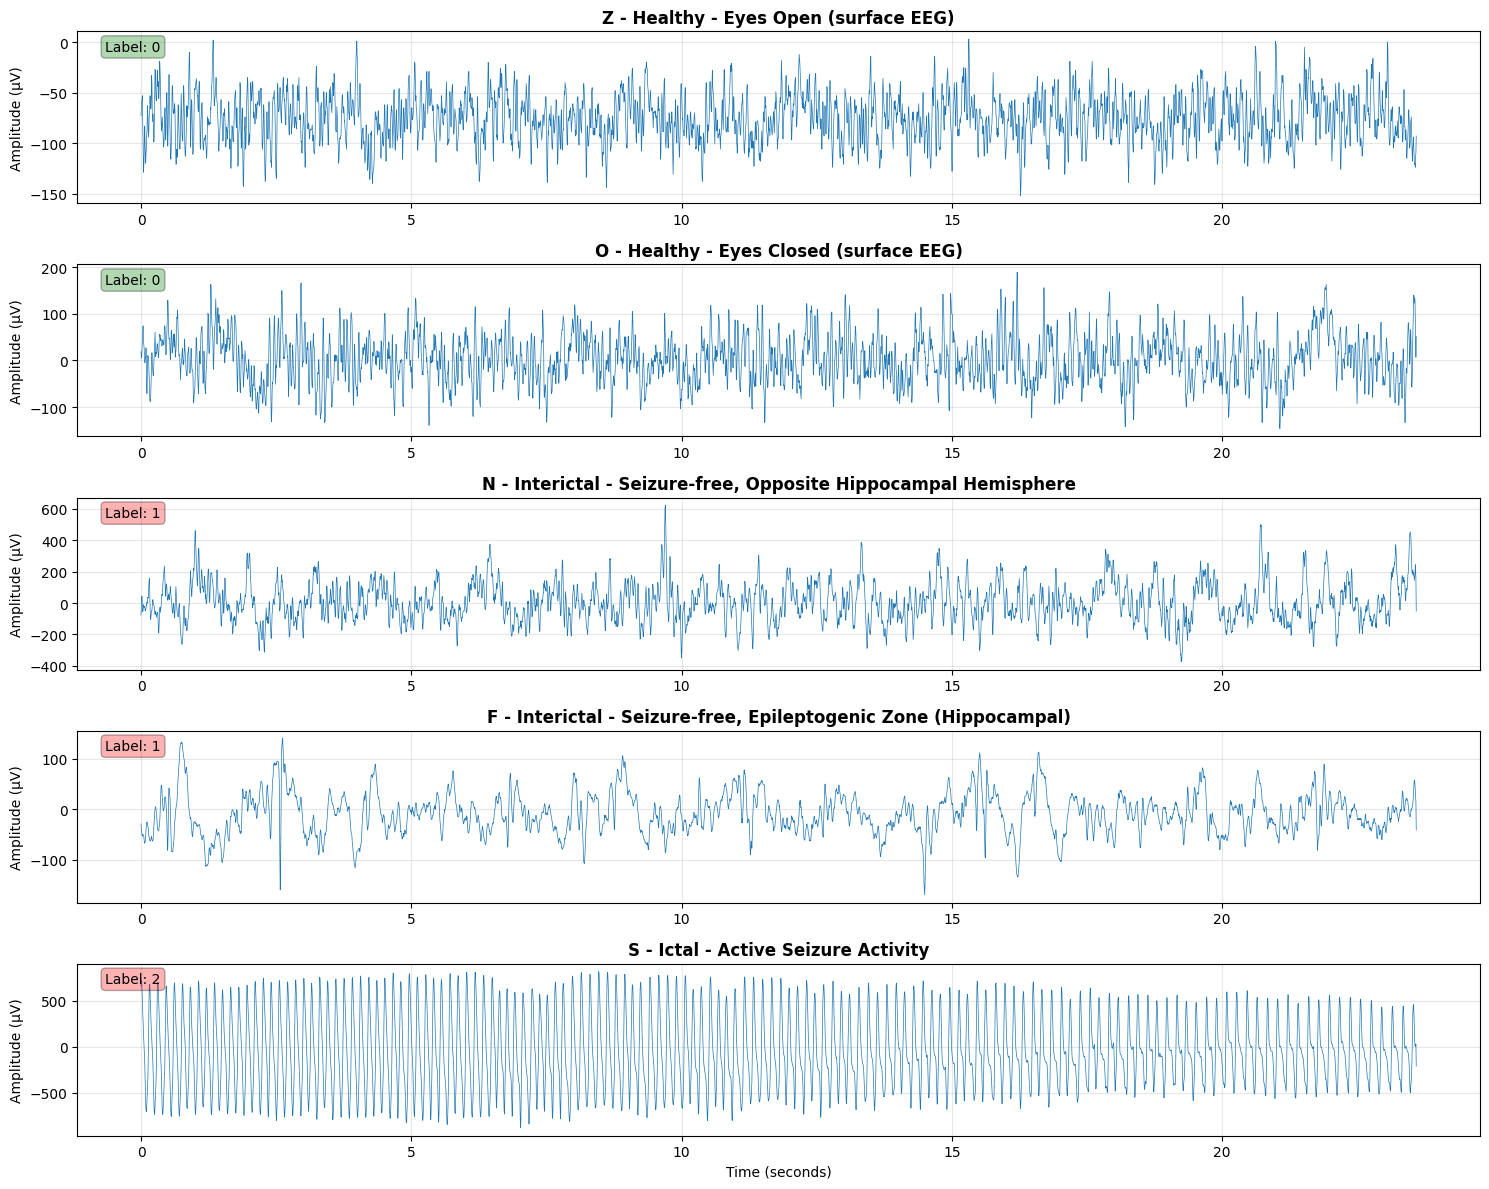

In [6]:
if len(datasets) > 0:
    # Plot sample signals from each class
    fig, axes = plt.subplots(5, 1, figsize=(15, 12))
    
    for i, (folder, data) in enumerate(datasets.items()):
        sample_signal = data[0]  # First signal from each folder
        time = np.arange(len(sample_signal)) / 173.61  # Convert to seconds
        
        axes[i].plot(time, sample_signal, linewidth=0.5)
        axes[i].set_title(f'{folder} - {mapping_set_to_dir[[k for k,v in mapping_set_to_dir.items() if v[1]==folder][0]][2]}', 
                         fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Amplitude (μV)')
        axes[i].grid(True, alpha=0.3)
        
        # Add label annotation
        label = labels_map[folder]
        color = 'green' if label == 0 else 'red'
        axes[i].text(0.02, 0.95, f'Label: {label}', 
                    transform=axes[i].transAxes, 
                    bbox=dict(boxstyle='round', facecolor=color, alpha=0.3),
                    verticalalignment='top')
    
    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.savefig('eeg_signals_overview.png', dpi=150, bbox_inches='tight')
    plt.show()

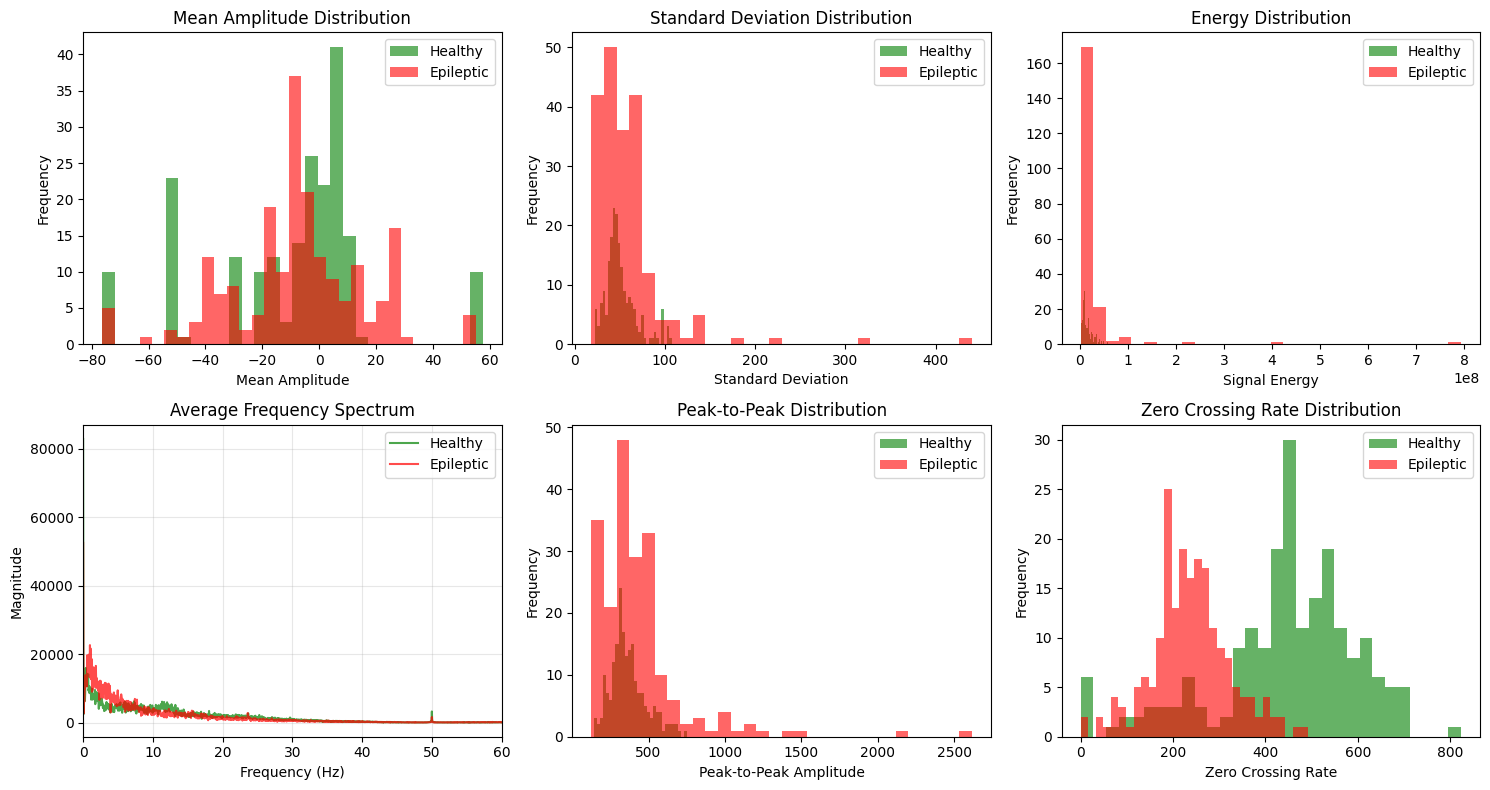

In [7]:
# Statistical comparison between healthy and epileptic
if len(all_signals) > 0:
    healthy_signals = all_signals[all_labels == 0]
    epileptic_signals = all_signals[all_labels == 1]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # Mean amplitude
    axes[0, 0].hist(np.mean(healthy_signals, axis=1), bins=30, alpha=0.6, label='Healthy', color='green')
    axes[0, 0].hist(np.mean(epileptic_signals, axis=1), bins=30, alpha=0.6, label='Epileptic', color='red')
    axes[0, 0].set_xlabel('Mean Amplitude')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Mean Amplitude Distribution')
    axes[0, 0].legend()
    
    # Standard deviation
    axes[0, 1].hist(np.std(healthy_signals, axis=1), bins=30, alpha=0.6, label='Healthy', color='green')
    axes[0, 1].hist(np.std(epileptic_signals, axis=1), bins=30, alpha=0.6, label='Epileptic', color='red')
    axes[0, 1].set_xlabel('Standard Deviation')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Standard Deviation Distribution')
    axes[0, 1].legend()
    
    # Energy
    axes[0, 2].hist(np.sum(healthy_signals**2, axis=1), bins=30, alpha=0.6, label='Healthy', color='green')
    axes[0, 2].hist(np.sum(epileptic_signals**2, axis=1), bins=30, alpha=0.6, label='Epileptic', color='red')
    axes[0, 2].set_xlabel('Signal Energy')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].set_title('Energy Distribution')
    axes[0, 2].legend()
    
    # Frequency spectrum (average)
    healthy_fft = np.mean([np.abs(fft(s)) for s in healthy_signals[:10]], axis=0)
    epileptic_fft = np.mean([np.abs(fft(s)) for s in epileptic_signals[:10]], axis=0)
    freqs = fftfreq(len(healthy_signals[0]), 1/173.61)
    
    axes[1, 0].plot(freqs[:len(freqs)//2], healthy_fft[:len(freqs)//2], label='Healthy', alpha=0.7, color='green')
    axes[1, 0].plot(freqs[:len(freqs)//2], epileptic_fft[:len(freqs)//2], label='Epileptic', alpha=0.7, color='red')
    axes[1, 0].set_xlabel('Frequency (Hz)')
    axes[1, 0].set_ylabel('Magnitude')
    axes[1, 0].set_title('Average Frequency Spectrum')
    axes[1, 0].set_xlim([0, 60])  # Focus on 0-60 Hz
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Peak-to-peak amplitude
    axes[1, 1].hist(np.ptp(healthy_signals, axis=1), bins=30, alpha=0.6, label='Healthy', color='green')
    axes[1, 1].hist(np.ptp(epileptic_signals, axis=1), bins=30, alpha=0.6, label='Epileptic', color='red')
    axes[1, 1].set_xlabel('Peak-to-Peak Amplitude')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Peak-to-Peak Distribution')
    axes[1, 1].legend()
    
    # Zero crossing rate
    healthy_zcr = [np.sum(np.diff(np.signbit(s))) for s in healthy_signals]
    epileptic_zcr = [np.sum(np.diff(np.signbit(s))) for s in epileptic_signals]
    axes[1, 2].hist(healthy_zcr, bins=30, alpha=0.6, label='Healthy', color='green')
    axes[1, 2].hist(epileptic_zcr, bins=30, alpha=0.6, label='Epileptic', color='red')
    axes[1, 2].set_xlabel('Zero Crossing Rate')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_title('Zero Crossing Rate Distribution')
    axes[1, 2].legend()
    
    plt.tight_layout()
    plt.savefig('statistical_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## Basic Preprocessing

### Standard preprocessing steps:
1. Bandpass filtering (0.5-60 Hz)
2. Normalization

  Processing 500/500 - Complete

Basic preprocessing complete: (500, 4097)


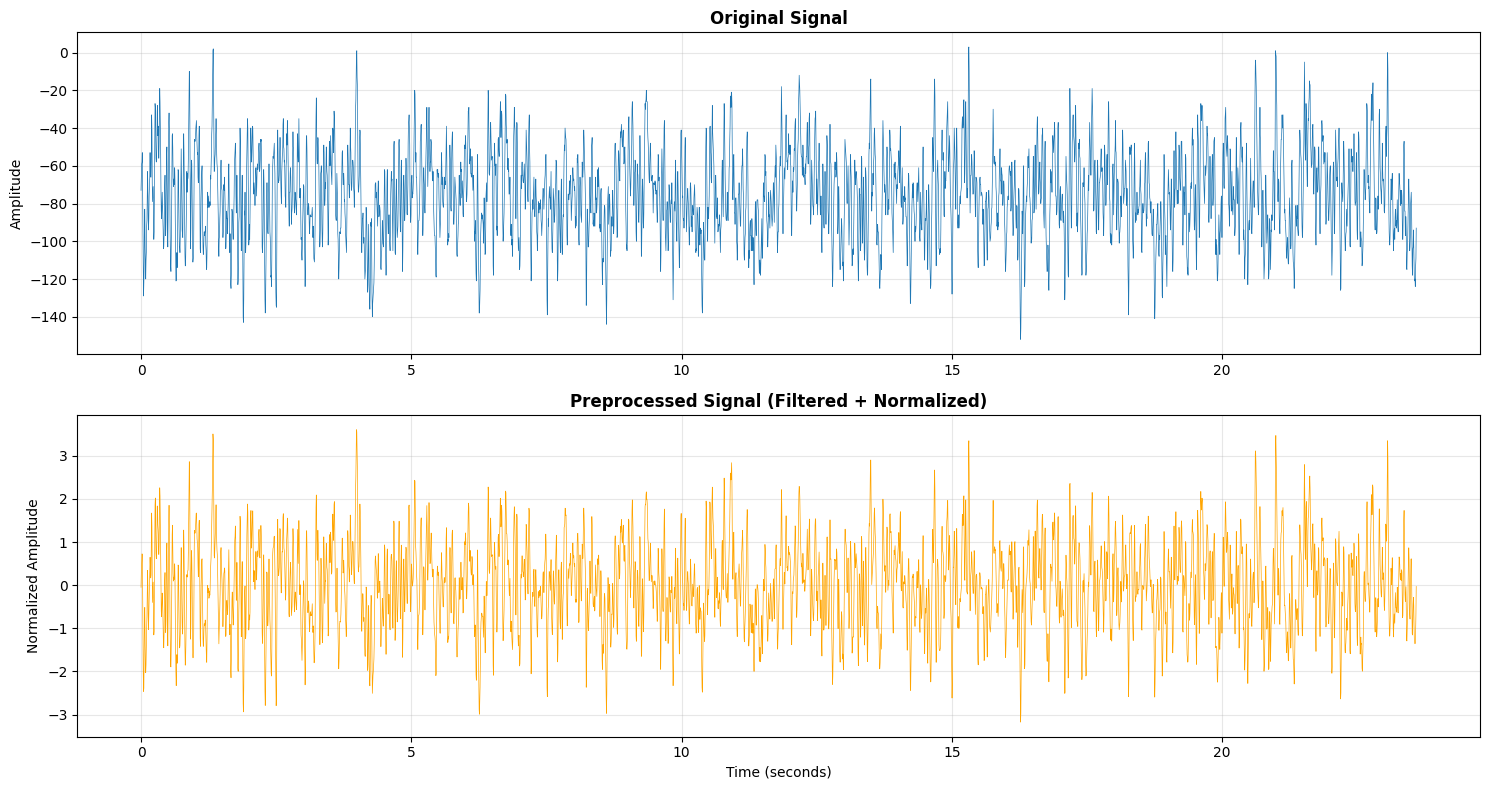

In [8]:
def bandpass_filter(sig, lowcut=0.5, highcut=60, fs=173.61, order=4):
    """
    Apply Butterworth bandpass filter
    
    Parameters:
    -----------
    sig : array
        Input signal
    lowcut : float
        Lower cutoff frequency (Hz)
    highcut : float
        Upper cutoff frequency (Hz)
    fs : float
        Sampling frequency (Hz)
    order : int
        Filter order
    
    Returns:
    --------
    filtered : array
        Filtered signal
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    filtered = signal.filtfilt(b, a, sig)
    return filtered

def normalize_signal(sig, method='zscore'):
    """
    Normalize signal
    
    Parameters:
    -----------
    sig : array
        Input signal
    method : str
        'zscore': zero mean, unit variance
        'minmax': scale to [0, 1]
    
    Returns:
    --------
    normalized : array
        Normalized signal
    """
    if method == 'zscore':
        return (sig - np.mean(sig)) / (np.std(sig) + 1e-8)
    elif method == 'minmax':
        return (sig - np.min(sig)) / (np.ptp(sig) + 1e-8)
    else:
        return sig

# Apply preprocessing
if len(all_signals) > 0:
    
    preprocessed_signals = []
    for i, sig in enumerate(all_signals):
        if i % 100 == 0:
            print(f"  Processing {i}/{len(all_signals)}", end='\r')
        
        # Bandpass filter
        filtered = bandpass_filter(sig)
        
        # Normalize
        normalized = normalize_signal(filtered, method='zscore')
        
        preprocessed_signals.append(normalized)
    
    preprocessed_signals = np.array(preprocessed_signals)
    print(f"  Processing {len(all_signals)}/{len(all_signals)} - Complete")
    print(f"\nBasic preprocessing complete: {preprocessed_signals.shape}")
    
    # Visualize effect of preprocessing
    fig, axes = plt.subplots(2, 1, figsize=(15, 8))
    
    sample_idx = 0
    time = np.arange(len(all_signals[sample_idx])) / 173.61
    
    axes[0].plot(time, all_signals[sample_idx], linewidth=0.5)
    axes[0].set_title('Original Signal', fontweight='bold')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(time, preprocessed_signals[sample_idx], linewidth=0.5, color='orange')
    axes[1].set_title('Preprocessed Signal (Filtered + Normalized)', fontweight='bold')
    axes[1].set_ylabel('Normalized Amplitude')
    axes[1].set_xlabel('Time (seconds)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('preprocessing_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## Advanced Preprocessing: Variational Mode Decomposition (VMD)

VMD decomposes signals into intrinsic mode functions (IMFs) representing different frequency bands.

In [9]:
def apply_vmd(signal, alpha=2000, tau=0, K=5, DC=0, init=1, tol=1e-7):
    """
    Apply Variational Mode Decomposition
    
    Parameters:
    -----------
    signal : array
        Input EEG signal
    alpha : float
        Balancing parameter for bandwidth constraint (higher = narrower bands)
    tau : float
        Time-step of dual ascent
    K : int
        Number of modes to extract
    DC : int
        Whether to impose DC part (first mode = 0 Hz)
    init : int
        Initialization method (0: all omegas start at 0, 1: uniformly distributed)
    tol : float
        Tolerance for convergence
    
    Returns:
    --------
    u : array
        Collection of decomposed modes (K x signal_length)
    omega : array
        Estimated mode center frequencies
    """
    u, u_hat, omega = VMD(signal, alpha, tau, K, DC, init, tol)
    return u, omega

# Test VMD on sample signals
if len(preprocessed_signals) > 0:
    print("Testing VMD decomposition")
    
    # Apply to one healthy and one epileptic signal
    healthy_idx = np.where(all_labels == 0)[0][0]
    epileptic_idx = np.where(all_labels == 1)[0][0]
    
    healthy_signal = preprocessed_signals[healthy_idx]
    epileptic_signal = preprocessed_signals[epileptic_idx]
    
    print("  Decomposing healthy signal...")
    healthy_imfs, healthy_freqs = apply_vmd(healthy_signal, K=5)
    
    print("  Decomposing epileptic signal...")
    epileptic_imfs, epileptic_freqs = apply_vmd(epileptic_signal, K=5)
    
    print(f"\n VMD decomposition complete")
    print(f"  Number of IMFs: {len(healthy_imfs)}")
    print(f"  Healthy signal center frequencies: {healthy_freqs}")
    print(f"  Epileptic signal center frequencies: {epileptic_freqs}")

Testing VMD decomposition
  Decomposing healthy signal...
  Decomposing epileptic signal...

 VMD decomposition complete
  Number of IMFs: 5
  Healthy signal center frequencies: [[0.         0.1        0.2        0.3        0.4       ]
 [0.01254645 0.09795479 0.18994465 0.28736799 0.24080103]
 [0.0151288  0.09613627 0.18231891 0.28511406 0.22505561]
 [0.01635651 0.0943016  0.1755451  0.28574749 0.21873549]
 [0.01699718 0.09240595 0.16895982 0.28597705 0.21334593]
 [0.01732224 0.09039725 0.16248534 0.28600174 0.20817228]
 [0.01746137 0.08822559 0.15619373 0.28597369 0.20321764]
 [0.01748372 0.08586302 0.1500096  0.28594176 0.1986241 ]
 [0.01742753 0.08332144 0.14392393 0.28591658 0.19453048]
 [0.01731421 0.08066622 0.13830151 0.28589363 0.19092805]
 [0.01715668 0.07801307 0.13364447 0.28586399 0.18770063]
 [0.01696556 0.07550081 0.13007756 0.28582445 0.18474715]
 [0.01675239 0.07324249 0.12733736 0.28577627 0.18201391]
 [0.01652955 0.07128818 0.1251525  0.2857201  0.17945849]
 [0.016308

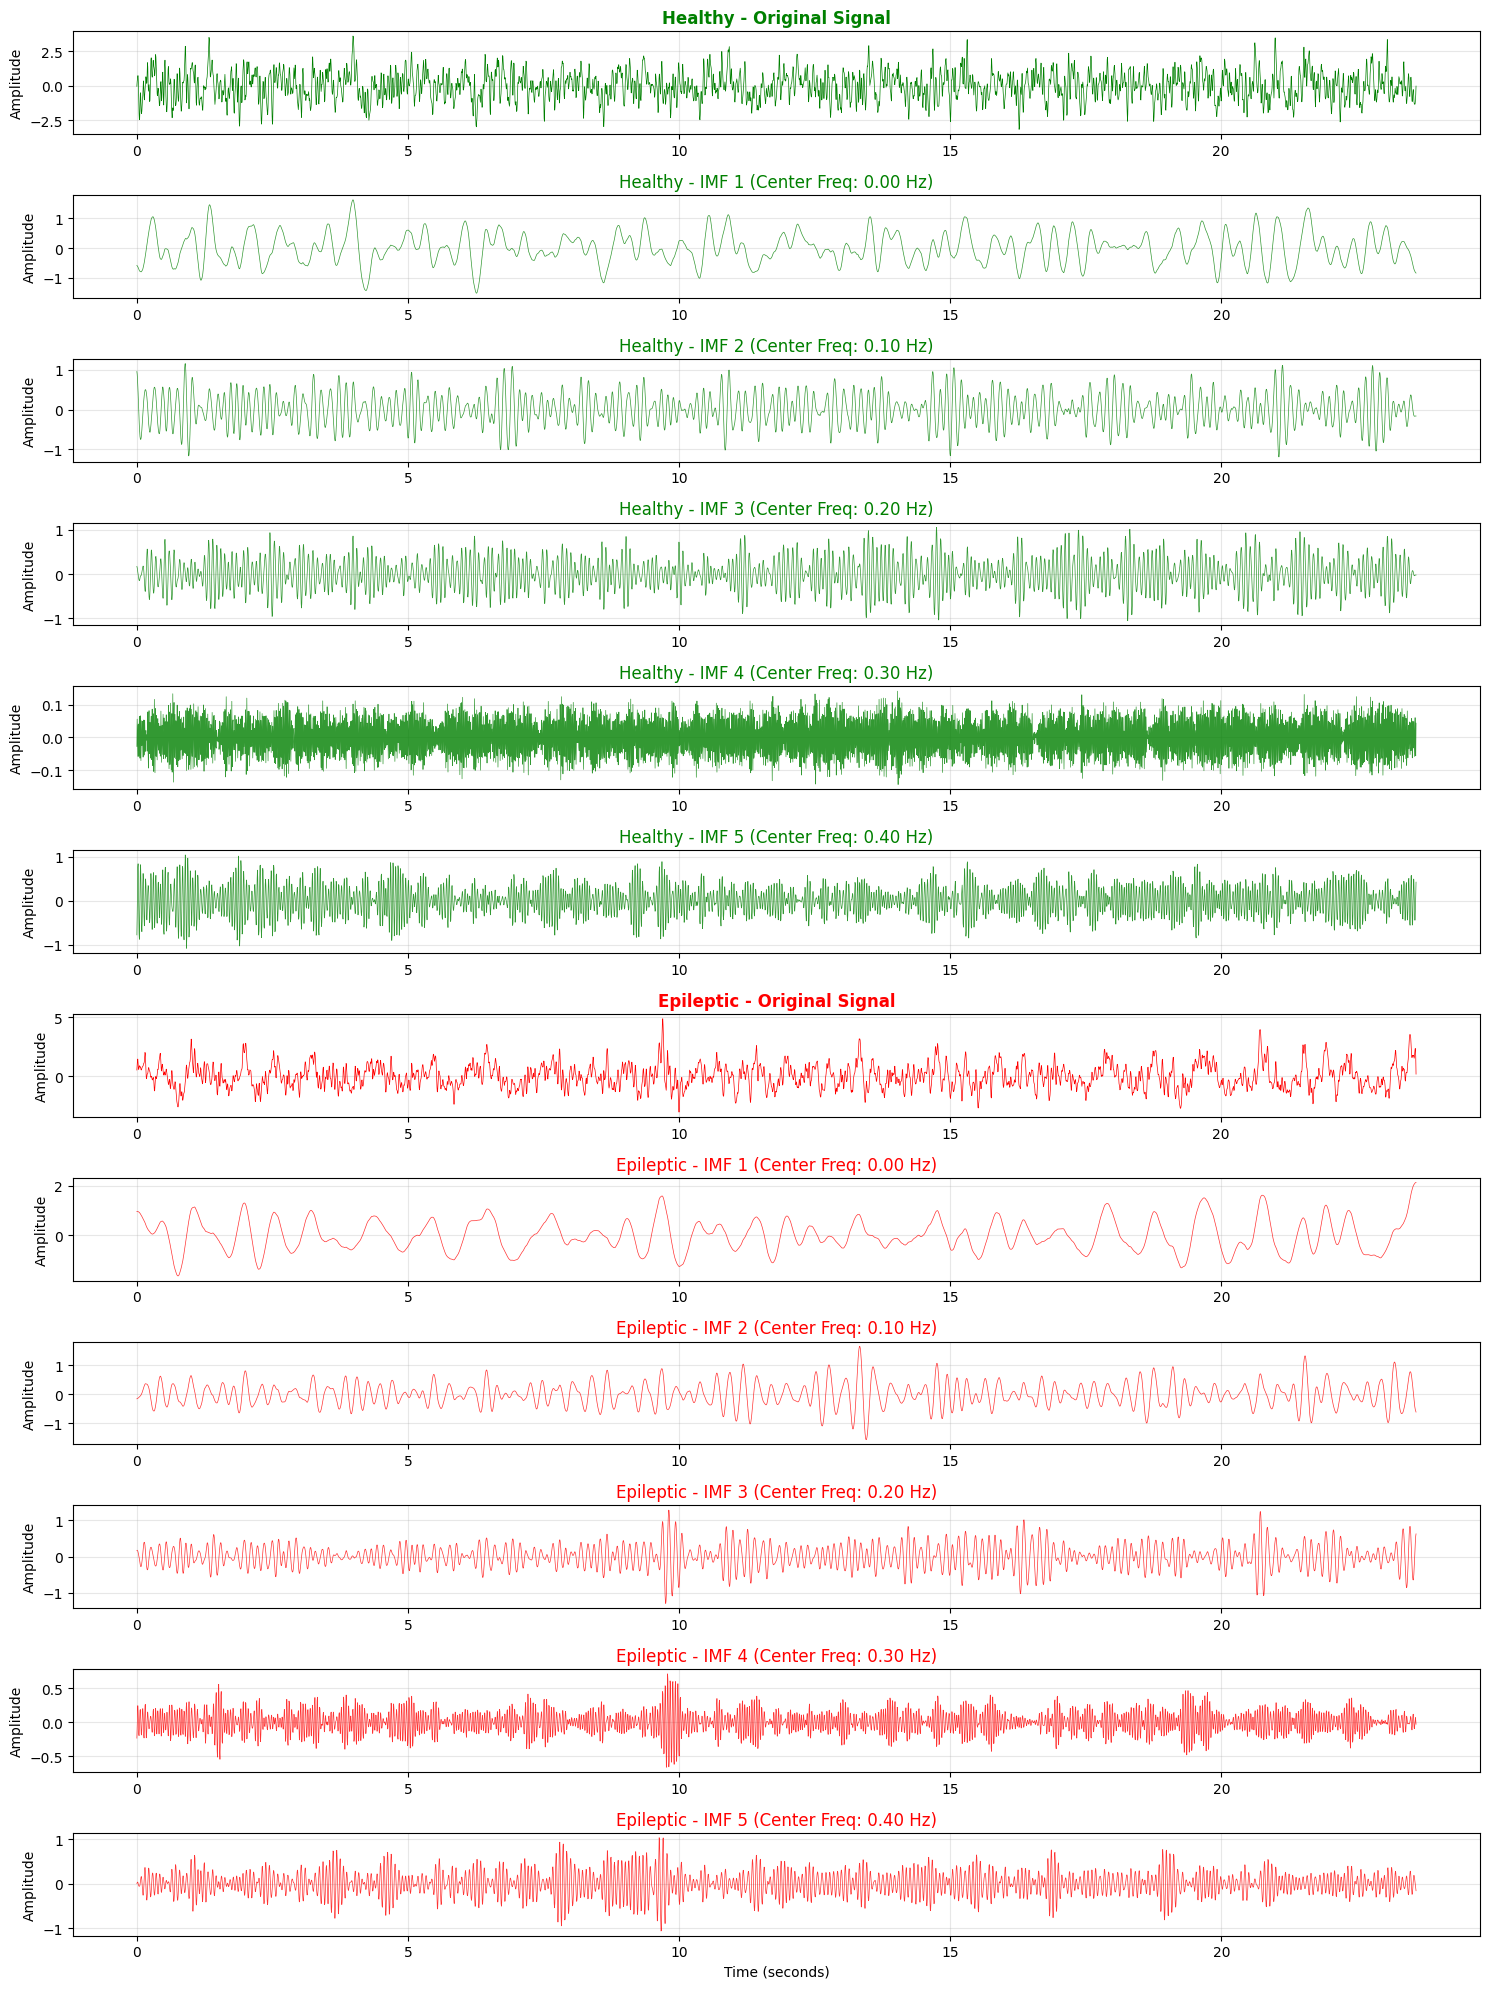

VMD decomposition visualization saved
Note: Original signal length: 4097, IMF length: 4096


In [10]:
# Visualize VMD decomposition
if len(preprocessed_signals) > 0:
    fig, axes = plt.subplots(12, 1, figsize=(15, 20))
    
    # Flatten frequency arrays to ensure 1D
    healthy_freqs_flat = np.array(healthy_freqs).flatten()
    epileptic_freqs_flat = np.array(epileptic_freqs).flatten()
    
    # Create time arrays for each signal length
    time_original = np.arange(len(healthy_signal)) / 173.61
    time_imf = np.arange(len(healthy_imfs[0])) / 173.61
    
    # Healthy signal - Original
    axes[0].plot(time_original, healthy_signal, linewidth=0.5, color='green')
    axes[0].set_title('Healthy - Original Signal', fontweight='bold', color='green')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)
    
    # Healthy IMFs
    for i in range(5):
        axes[i+1].plot(time_imf, healthy_imfs[i], linewidth=0.5, color='green', alpha=0.8)
        axes[i+1].set_title(f'Healthy - IMF {i+1} (Center Freq: {healthy_freqs_flat[i]:.2f} Hz)', color='green')
        axes[i+1].set_ylabel('Amplitude')
        axes[i+1].grid(True, alpha=0.3)
    
    # Epileptic signal - Original
    time_epileptic = np.arange(len(epileptic_signal)) / 173.61
    time_epileptic_imf = np.arange(len(epileptic_imfs[0])) / 173.61
    
    axes[6].plot(time_epileptic, epileptic_signal, linewidth=0.5, color='red')
    axes[6].set_title('Epileptic - Original Signal', fontweight='bold', color='red')
    axes[6].set_ylabel('Amplitude')
    axes[6].grid(True, alpha=0.3)
    
    # Epileptic IMFs
    for i in range(5):
        axes[i+7].plot(time_epileptic_imf, epileptic_imfs[i], linewidth=0.5, color='red', alpha=0.8)
        axes[i+7].set_title(f'Epileptic - IMF {i+1} (Center Freq: {epileptic_freqs_flat[i]:.2f} Hz)', color='red')
        axes[i+7].set_ylabel('Amplitude')
        axes[i+7].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.savefig('vmd_decomposition_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("VMD decomposition visualization saved")
    print(f"Note: Original signal length: {len(healthy_signal)}, IMF length: {len(healthy_imfs[0])}")

## Entropy-Based Feature Extraction

Extract multiple entropy measures from each IMF to capture complexity and regularity.

In [11]:
def extract_entropy_features(imf):
    features = {}
    
    try:
        features['sample_entropy'] = float(ant.sample_entropy(imf))
    except:
        features['sample_entropy'] = 0.0
    
    try:
        features['approximate_entropy'] = float(ant.app_entropy(imf))
    except:
        features['approximate_entropy'] = 0.0
    
    try:
        features['permutation_entropy'] = float(ant.perm_entropy(imf, normalize=True))
    except:
        features['permutation_entropy'] = 0.0
    
    try:
        features['spectral_entropy'] = float(ant.spectral_entropy(imf, sf=173.61, method='welch', normalize=True))
    except:
        features['spectral_entropy'] = 0.0
    
    try:
        features['svd_entropy'] = float(ant.svd_entropy(imf, normalize=True))
    except:
        features['svd_entropy'] = 0.0
    
    try:
        hjorth = ant.hjorth_params(imf)
        features['hjorth_mobility'] = float(hjorth[0])
        features['hjorth_complexity'] = float(hjorth[1])
    except:
        features['hjorth_mobility'] = 0.0
        features['hjorth_complexity'] = 0.0
    
    # Statistical features - all explicitly cast to float
    features['mean']     = float(np.mean(imf))
    features['std']      = float(np.std(imf))
    features['variance'] = float(np.var(imf))
    features['skewness'] = float(pd.Series(imf).skew())
    features['kurtosis'] = float(pd.Series(imf).kurtosis())
    features['energy']   = float(np.sum(imf**2))
    features['rms']      = float(np.sqrt(np.mean(imf**2)))
    
    # Frequency domain features
    fft_vals = np.fft.fft(imf)
    psd = np.abs(fft_vals)**2
    spectral_centroid = float(np.sum(np.arange(len(psd)) * psd) / (np.sum(psd) + 1e-8))
    features['spectral_centroid'] = spectral_centroid
    features['spectral_spread']   = float(np.sqrt(np.sum(((np.arange(len(psd)) - spectral_centroid)**2) * psd) / (np.sum(psd) + 1e-8)))
    
    return features


def extract_all_features(signal, n_modes=5):
    # Apply VMD
    imfs, omega = apply_vmd(signal, K=n_modes)
    
    # Flatten omega to ensure it's 1D
    omega_flat = np.array(omega)[-1, :] 
    
    all_features = []
    feature_names = []
    
    for i, imf in enumerate(imfs):
        imf_features = extract_entropy_features(imf)
        for feat_name, feat_value in imf_features.items():
            all_features.append(float(feat_value))  # Force scalar float
            feature_names.append(f'IMF{i+1}_{feat_name}')
    
    # Add center frequencies
    for i, freq in enumerate(omega_flat):
        all_features.append(float(freq))  # Force scalar float
        feature_names.append(f'IMF{i+1}_center_freq')
    
    return np.array(all_features, dtype=np.float64), feature_names

In [12]:
X_features = []
y_features = []

print("Extracting features from all signals...")
for i, (sig, label) in enumerate(zip(preprocessed_signals, all_labels)):
    if i % 50 == 0:
        print(f"  Processing {i}/{len(preprocessed_signals)}", end='\r')
    
    features, feature_names = extract_all_features(sig, n_modes=5)
    X_features.append(features)
    y_features.append(label)

print(f"  Processing {len(preprocessed_signals)}/{len(preprocessed_signals)} - Complete!")

Extracting features from all signals...
  Processing 500/500 - Complete!


In [13]:
# Check all feature vectors have the same length
feature_lengths = [len(f) for f in X_features]
print(f"\nFeature vector lengths - Min: {min(feature_lengths)}, Max: {max(feature_lengths)}, Expected: {feature_lengths[0]}")

# Find the most common length
from collections import Counter
length_counts = Counter(feature_lengths)
expected_length = length_counts.most_common(1)[0][0]
print(f"Most common length: {expected_length} (appears in {length_counts[expected_length]}/{len(X_features)} signals)")

# Filter out any signals with wrong length
X_features_clean = []
y_features_clean = []

for feat, label in zip(X_features, y_features):
    if len(feat) == expected_length:
        X_features_clean.append(feat)
        y_features_clean.append(label)
    else:
        print(f"  Dropped signal with feature length {len(feat)}")

X_features = np.array(X_features_clean, dtype=np.float64)
y_features = np.array(y_features_clean)

print(f"\nFeature extraction complete")
print(f"  Feature matrix shape: {X_features.shape}")
print(f"  Labels shape: {y_features.shape}")
print(f"  Features per signal: {X_features.shape[1]}")
print(f"  Dropped signals: {500 - len(X_features_clean)}")

# Save features
np.save('extracted_features.npy', X_features)
np.save('feature_labels.npy', y_features)
print("\n Features saved to extracted_features.npy and feature_labels.npy")


Feature vector lengths - Min: 85, Max: 85, Expected: 85
Most common length: 85 (appears in 500/500 signals)

Feature extraction complete
  Feature matrix shape: (500, 85)
  Labels shape: (500,)
  Features per signal: 85
  Dropped signals: 0

 Features saved to extracted_features.npy and feature_labels.npy


## 7. Feature Selection

Reduce dimensionality by selecting most informative features.


Performing feature selection (mutual_info)
  Original features: 85
  Selected features: 50
  Reduction: 41.2%


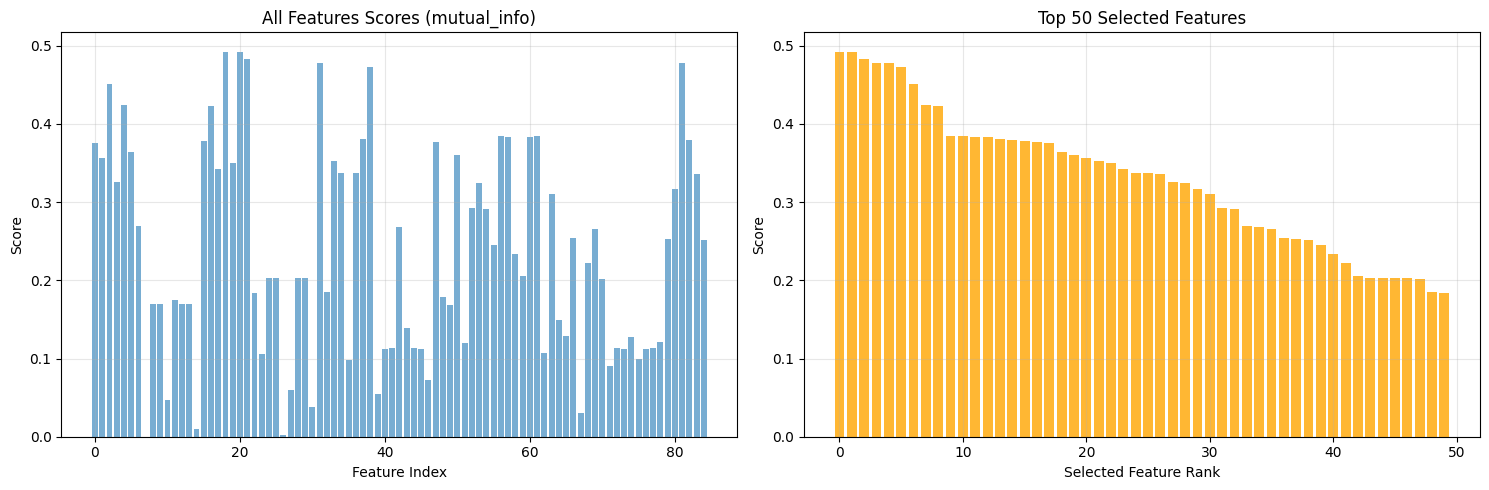


 Feature selection complete


In [14]:
def perform_feature_selection(X, y, n_features=50, method='mutual_info'):
    """
    Perform feature selection using multiple methods
    
    Parameters:
    X : array
        Feature matrix
    y : array
        Labels
    n_features : int
        Number of features to select
    method : str
        'mutual_info', 'f_score', or 'hybrid'
    
    Returns:
    X_selected : array
        Selected features
    scaler : StandardScaler
        Fitted scaler for future use
    selector : SelectKBest
        Fitted selector for future use
    selected_indices : array
        Indices of selected features
    """
    print(f"\nPerforming feature selection ({method})")
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    if method == 'mutual_info':
        selector = SelectKBest(score_func=mutual_info_classif, k=min(n_features, X.shape[1]))
    elif method == 'f_score':
        selector = SelectKBest(score_func=f_classif, k=min(n_features, X.shape[1]))
    elif method == 'hybrid':
        # Use both methods and take union
        selector1 = SelectKBest(score_func=mutual_info_classif, k=min(n_features//2, X.shape[1]))
        selector2 = SelectKBest(score_func=f_classif, k=min(n_features//2, X.shape[1]))
        
        X_selected1 = selector1.fit_transform(X_scaled, y)
        X_selected2 = selector2.fit_transform(X_scaled, y)
        
        X_selected = np.hstack([X_selected1, X_selected2])
        
        print(f"  Selected {X_selected.shape[1]} features (hybrid method)")
        return X_selected, scaler, (selector1, selector2), None
    
    X_selected = selector.fit_transform(X_scaled, y)
    selected_indices = selector.get_support(indices=True)
    feature_scores = selector.scores_
    
    print(f"  Original features: {X.shape[1]}")
    print(f"  Selected features: {X_selected.shape[1]}")
    print(f"  Reduction: {(1 - X_selected.shape[1]/X.shape[1])*100:.1f}%")
    
    # Plot feature importance
    if len(selected_indices) <= 50:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # All feature scores
        axes[0].bar(range(len(feature_scores)), feature_scores, alpha=0.6)
        axes[0].set_xlabel('Feature Index')
        axes[0].set_ylabel('Score')
        axes[0].set_title(f'All Features Scores ({method})')
        axes[0].grid(True, alpha=0.3)
        
        # Selected features
        selected_scores = feature_scores[selected_indices]
        axes[1].bar(range(len(selected_scores)), sorted(selected_scores, reverse=True), color='orange', alpha=0.8)
        axes[1].set_xlabel('Selected Feature Rank')
        axes[1].set_ylabel('Score')
        axes[1].set_title(f'Top {len(selected_indices)} Selected Features')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('feature_selection_scores.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    print(f"\n Feature selection complete")
    return X_selected, scaler, selector, selected_indices

# Apply feature selection
if len(preprocessed_signals) > 0 and X_features is not None:
    X_selected, scaler, selector, selected_indices = perform_feature_selection(
        X_features, y_features, 
        n_features=50, 
        method='mutual_info'
    )

## Feature Fusion with PCA

Apply PCA for dimensionality reduction and feature fusion.


Applying PCA for feature fusion
  Original features: 50
  Principal components: 30
  Reduction: 40.0%
  Cumulative explained variance: 0.9997
  Components for 95% variance: 13


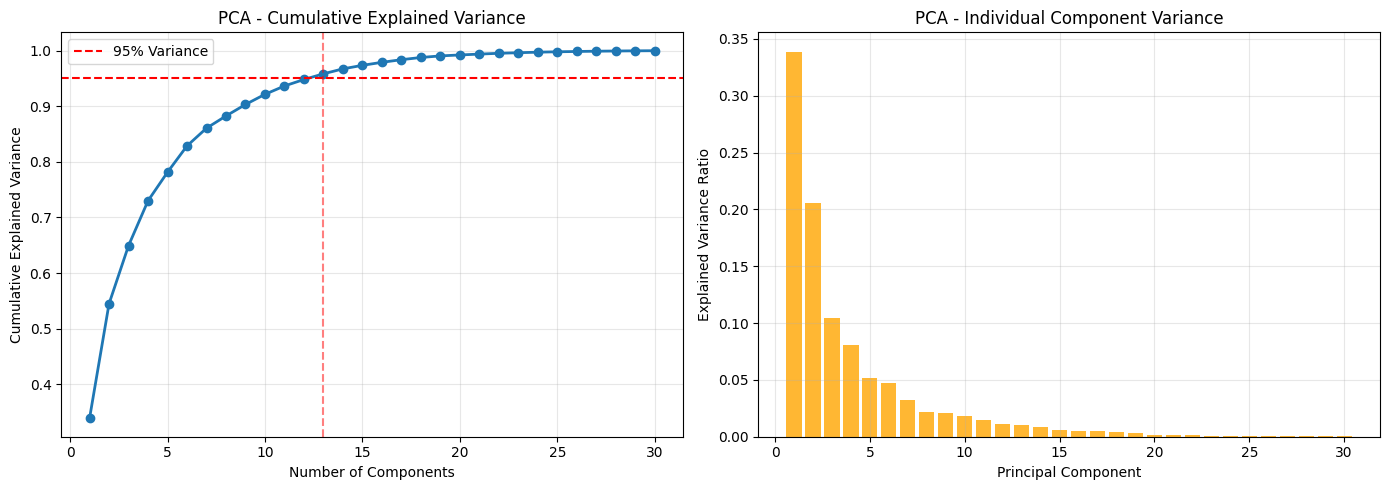

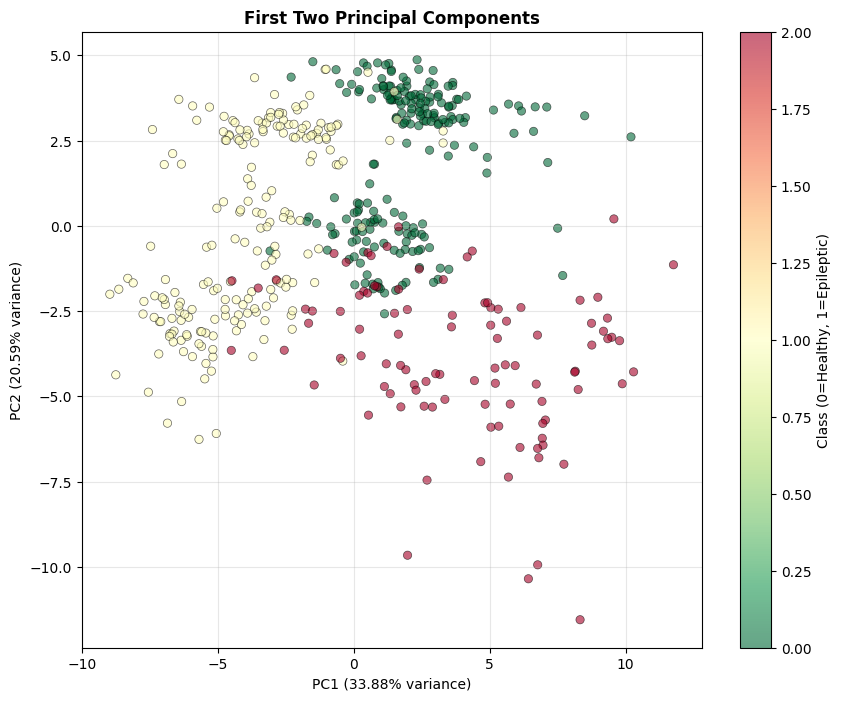


 PCA feature fusion complete


In [15]:
def feature_fusion_pca(X, n_components=30):
    """
    Apply PCA for feature fusion and dimensionality reduction
    
    Parameters:
    X : array
        Feature matrix
    n_components : int
        Number of principal components
    
    Returns:
    X_fused : array
        Transformed features
    pca : PCA
        Fitted PCA transformer
    """
    print(f"\nApplying PCA for feature fusion")
    
    pca = PCA(n_components=min(n_components, X.shape[1]))
    X_fused = pca.fit_transform(X)
    
    cumsum_variance = np.cumsum(pca.explained_variance_ratio_)
    
    print(f"  Original features: {X.shape[1]}")
    print(f"  Principal components: {X_fused.shape[1]}")
    print(f"  Reduction: {(1 - X_fused.shape[1]/X.shape[1])*100:.1f}%")
    print(f"  Cumulative explained variance: {cumsum_variance[-1]:.4f}")
    
    # Find number of components for 95% variance
    n_95 = np.argmax(cumsum_variance >= 0.95) + 1
    print(f"  Components for 95% variance: {n_95}")
    
    # Plot explained variance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Cumulative variance
    axes[0].plot(range(1, len(cumsum_variance)+1), cumsum_variance, marker='o', linewidth=2)
    axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
    axes[0].axvline(x=n_95, color='r', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Number of Components')
    axes[0].set_ylabel('Cumulative Explained Variance')
    axes[0].set_title('PCA - Cumulative Explained Variance')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Individual variance
    axes[1].bar(range(1, len(pca.explained_variance_ratio_)+1), 
                pca.explained_variance_ratio_, alpha=0.8, color='orange')
    axes[1].set_xlabel('Principal Component')
    axes[1].set_ylabel('Explained Variance Ratio')
    axes[1].set_title('PCA - Individual Component Variance')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('pca_variance_explained.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Visualize first two components
    if X_fused.shape[1] >= 2:
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(X_fused[:, 0], X_fused[:, 1], 
                            c=y_features, cmap='RdYlGn_r', 
                            alpha=0.6, edgecolors='black', linewidth=0.5)
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
        plt.title('First Two Principal Components', fontweight='bold')
        cbar = plt.colorbar(scatter)
        cbar.set_label('Class (0=Healthy, 1=Epileptic)')
        plt.grid(True, alpha=0.3)
        plt.savefig('pca_2d_visualization.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    print(f"\n PCA feature fusion complete")
    return X_fused, pca

# Apply PCA
if len(preprocessed_signals) > 0 and X_selected is not None:
    X_fused, pca = feature_fusion_pca(X_selected, n_components=30)

## Handle Class Imbalance with ADASYN

ADASYN (Adaptive Synthetic Sampling) generates synthetic samples for the minority class.

In [16]:
def apply_adasyn(X, y, sampling_strategy='auto', random_state=42):
    print(f"\nApplying ADASYN for class balancing")
    print(f"  Original class distribution:")
    unique, counts = np.unique(y, return_counts=True)
    for label, count in zip(unique, counts):
        print(f"    Class {label}: {count} samples ({count/len(y)*100:.1f}%)")
    
    try:
        adasyn = ADASYN(sampling_strategy=sampling_strategy, random_state=random_state, n_neighbors=5)
        X_resampled, y_resampled = adasyn.fit_resample(X, y)
        method_used = 'ADASYN'
    except Exception as e:
        print(f"  ADASYN failed: {e}")
        print(f"  Falling back to SMOTE")
        smote = SMOTE(sampling_strategy=sampling_strategy, random_state=random_state)
        X_resampled, y_resampled = smote.fit_resample(X, y)
        method_used = 'SMOTE'
    
    print(f"\n  Resampled class distribution ({method_used}):")
    unique_r, counts_r = np.unique(y_resampled, return_counts=True)
    for label, count in zip(unique_r, counts_r):
        print(f"    Class {label}: {count} samples ({count/len(y_resampled)*100:.1f}%)")
    
    print(f"\n  Original samples:  {len(y)}")
    print(f"  Resampled samples: {len(y_resampled)}")
    print(f"  Synthetic samples added: {len(y_resampled) - len(y)}")
    
    # Visualize - dynamically built for any number of classes
    class_names = {0: 'Healthy', 1: 'Interictal', 2: 'Ictal'}
    colors      = {0: 'green',   1: 'orange',      2: 'red'}
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Before
    unique_before, counts_before = np.unique(y, return_counts=True)
    labels_before = [class_names.get(l, f'Class {l}') for l in unique_before]
    bar_colors_before = [colors.get(l, 'blue') for l in unique_before]
    axes[0].bar(labels_before, counts_before, color=bar_colors_before, alpha=0.7)
    axes[0].set_title('Original Class Distribution', fontweight='bold')
    axes[0].set_ylabel('Number of Samples')
    axes[0].grid(True, alpha=0.3, axis='y')
    for i, count in enumerate(counts_before):
        axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')
    
    # After
    unique_after, counts_after = np.unique(y_resampled, return_counts=True)
    labels_after = [class_names.get(l, f'Class {l}') for l in unique_after]
    bar_colors_after = [colors.get(l, 'blue') for l in unique_after]
    axes[1].bar(labels_after, counts_after, color=bar_colors_after, alpha=0.7)
    axes[1].set_title(f'After {method_used}', fontweight='bold')
    axes[1].set_ylabel('Number of Samples')
    axes[1].grid(True, alpha=0.3, axis='y')
    for i, count in enumerate(counts_after):
        axes[1].text(i, count + 5, str(count), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('class_balance_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nClass balancing complete using {method_used}")
    return X_resampled, y_resampled

## Train-Test Split

 X_balanced not found - running ADASYN now

Applying ADASYN for class balancing
  Original class distribution:
    Class 0: 200 samples (40.0%)
    Class 1: 200 samples (40.0%)
    Class 2: 100 samples (20.0%)

  Resampled class distribution (ADASYN):
    Class 0: 200 samples (33.3%)
    Class 1: 200 samples (33.3%)
    Class 2: 201 samples (33.4%)

  Original samples:  500
  Resampled samples: 601
  Synthetic samples added: 101


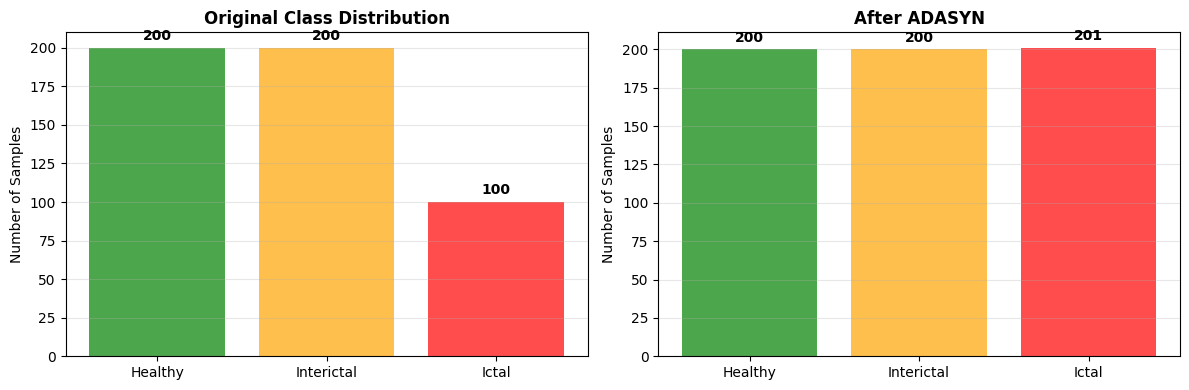


Class balancing complete using ADASYN
TRAIN-TEST SPLIT SUMMARY
Training set: (480, 30)
Test set:     (121, 30)

Training labels distribution:
  Healthy: 160 samples (33.3%)
  Interictal: 160 samples (33.3%)
  Ictal: 160 samples (33.3%)

Test labels distribution:
  Healthy: 40 samples (33.1%)
  Interictal: 40 samples (33.1%)
  Ictal: 41 samples (33.9%)

Data saved: X_train.npy, X_test.npy, y_train.npy, y_test.npy


In [17]:
# Split data
try:
    X_balanced
    y_balanced
except NameError:
    print(" X_balanced not found - running ADASYN now")
    X_balanced, y_balanced = apply_adasyn(X_fused, y_features)

if len(preprocessed_signals) > 0 and X_balanced is not None:
    X_train, X_test, y_train, y_test = train_test_split(
        X_balanced, y_balanced,
        test_size=0.2,
        random_state=42,
        stratify=y_balanced
    )
    
    print("TRAIN-TEST SPLIT SUMMARY")
    print(f"Training set: {X_train.shape}")
    print(f"Test set:     {X_test.shape}")
    print(f"\nTraining labels distribution:")
    unique, counts = np.unique(y_train, return_counts=True)
    class_names = {0: 'Healthy', 1: 'Interictal', 2: 'Ictal'}
    for label, count in zip(unique, counts):
        print(f"  {class_names.get(label, label)}: {count} samples ({count/len(y_train)*100:.1f}%)")
    print(f"\nTest labels distribution:")
    unique, counts = np.unique(y_test, return_counts=True)
    for label, count in zip(unique, counts):
        print(f"  {class_names.get(label, label)}: {count} samples ({count/len(y_test)*100:.1f}%)")

    # Save
    np.save('X_train.npy', X_train)
    np.save('X_test.npy', X_test)
    np.save('y_train.npy', y_train)
    np.save('y_test.npy', y_test)
    
    print("\nData saved: X_train.npy, X_test.npy, y_train.npy, y_test.npy")

## Save Preprocessing Objects

Save all preprocessing objects for use during inference.

In [18]:
import pickle

if len(preprocessed_signals) > 0:
    # Check all objects exist before saving
    required = {'scaler': scaler, 'selector': selector, 'pca': pca}
    
    missing = []
    for name, obj in required.items():
        try:
            obj
        except NameError:
            missing.append(name)
    
    if missing:
        print(f" Missing objects: {missing}")
    else:
        preprocessing_objects = {
            'scaler':        scaler,
            'selector':      selector,
            'pca':           pca,
            'feature_names': feature_names if 'feature_names' in dir() else [],
            'n_modes':       5,
            'sampling_rate': 173.61,
            'n_classes':     3,
            'class_map':     {0: 'Healthy', 1: 'Interictal', 2: 'Ictal'},
            'labels_map':    {'Z': 0, 'O': 0, 'N': 1, 'F': 1, 'S': 2}
        }
        
        with open('preprocessing_pipeline.pkl', 'wb') as f:
            pickle.dump(preprocessing_objects, f)
        
        print("Preprocessing pipeline saved to: preprocessing_pipeline.pkl")
        print("\nThis file contains:")
        for key, val in preprocessing_objects.items():
            print(f"  - {key}: {type(val).__name__}")
        
        print("\n To reload later in your model training notebook:")
        print("   import pickle")
        print("   with open('preprocessing_pipeline.pkl', 'rb') as f:")
        print("       pipeline = pickle.load(f)")
        print("   scaler   = pipeline['scaler']")
        print("   selector = pipeline['selector']")
        print("   pca      = pipeline['pca']")

Preprocessing pipeline saved to: preprocessing_pipeline.pkl

This file contains:
  - scaler: StandardScaler
  - selector: SelectKBest
  - pca: PCA
  - feature_names: list
  - n_modes: int
  - sampling_rate: float
  - n_classes: int
  - class_map: dict
  - labels_map: dict

 To reload later in your model training notebook:
   import pickle
   with open('preprocessing_pipeline.pkl', 'rb') as f:
       pipeline = pickle.load(f)
   scaler   = pipeline['scaler']
   selector = pipeline['selector']
   pca      = pipeline['pca']


## Preprocessing Summary and Next Steps

In [19]:
if len(preprocessed_signals) > 0 and X_balanced is not None:
    print("\n DATA PIPELINE SUMMARY:")
    print(f"  1. Raw signals loaded: {len(all_signals)}")
    print(f"  2. After basic preprocessing: {len(preprocessed_signals)}")
    print(f"  3. After VMD + feature extraction: {X_features.shape}")
    print(f"  4. After feature selection: {X_selected.shape}")
    print(f"  5. After PCA fusion: {X_fused.shape}")
    print(f"  6. After ADASYN balancing: {X_balanced.shape}")
    print(f"  7. Final training set: {X_train.shape}")
    print(f"  8. Final test set: {X_test.shape}")
    
    print("\n FILES GENERATED:")
    print("  Visualizations:")
    print("    - eeg_signals_overview.png")
    print("    - statistical_comparison.png")
    print("    - preprocessing_comparison.png")
    print("    - vmd_decomposition_comparison.png")
    print("    - feature_selection_scores.png")
    print("    - pca_variance_explained.png")
    print("    - pca_2d_visualization.png")
    print("    - class_balance_comparison.png")
    print("\n  Data files:")
    print("    - extracted_features.npy")
    print("    - feature_labels.npy")
    print("    - X_train.npy")
    print("    - X_test.npy")
    print("    - y_train.npy")
    print("    - y_test.npy")
    print("\n  Pipeline objects:")
    print("    - preprocessing_pipeline.pkl")


 DATA PIPELINE SUMMARY:
  1. Raw signals loaded: 500
  2. After basic preprocessing: 500
  3. After VMD + feature extraction: (500, 85)
  4. After feature selection: (500, 50)
  5. After PCA fusion: (500, 30)
  6. After ADASYN balancing: (601, 30)
  7. Final training set: (480, 30)
  8. Final test set: (121, 30)

 FILES GENERATED:
  Visualizations:
    - eeg_signals_overview.png
    - statistical_comparison.png
    - preprocessing_comparison.png
    - vmd_decomposition_comparison.png
    - feature_selection_scores.png
    - pca_variance_explained.png
    - pca_2d_visualization.png
    - class_balance_comparison.png

  Data files:
    - extracted_features.npy
    - feature_labels.npy
    - X_train.npy
    - X_test.npy
    - y_train.npy
    - y_test.npy

  Pipeline objects:
    - preprocessing_pipeline.pkl
